In [1]:
import re
import time
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from transformers import DistilBertTokenizer, DistilBertModel

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    matthews_corrcoef
)

from tqdm import tqdm


2025-07-26 22:32:06.786100: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753569126.965611      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753569127.022268      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Set up logging
logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger(__name__)



In [3]:
# Set random seeds for reproducibility
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [4]:
# Load data with error handling

def load_data(file_path):
    try:
        df = pd.read_csv(file_path)
        logger.info("Dataset loaded successfully.")
        return df
    except FileNotFoundError:
        logger.error("Dataset file not found.")
        raise
data = load_data("/kaggle/input/enron-spam-data/enron_spam_data.csv")


In [5]:
# Optimized text cleaning
from bs4 import BeautifulSoup
import re

def clean_text(text):
    if pd.isna(text):
        return ""
    # Remove HTML tags
    text = BeautifulSoup(text, 'html.parser').get_text(separator=' ')
    # Preserve more characters for URLs (e.g., [], {}, quotes)
    text = re.sub(r'[^\w\s!?.@#$%&*+\-=/:[{\]}''"]', ' ', text)  # Added [], {}, ' "
    # Replace multiple whitespace/newlines with single space
    text = re.sub(r'\s+', ' ', text).strip()
    # Lowercase
    text = text.lower()
    return text

In [6]:
    def preprocess_data(df):
        df['Text'] = df['Subject'].fillna('') + ' ' + df['Message'].fillna('')
        df['Text'] = df['Text'].apply(clean_text)
        df['Text'] = df['Text'].str.slice(0, 10000)  # Cap length post-cleaning
        df['Spam/Ham'] = df['Spam/Ham'].map({'spam': 1, 'ham': 0})
        df = df.dropna(subset=['Text', 'Spam/Ham'])
        return df

In [7]:
def engineer_features(df):
    """
    Engineer features for spam detection model.
    Returns features array and scaler.
    """
    # Initialize features array with 5 columns (excluding num_urls)
    features = np.zeros((len(df), 5))
    
    # 1. Text Length (capped at 10,000 characters)
    features[:, 0] = df['Text'].str.len().clip(upper=10000)
    
    # 2. Number of Exclamations (capped at 50)
    features[:, 1] = df['Text'].str.count('!').clip(upper=50).astype(float)
    
    # 3. Weekday (handle invalid dates)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')  # Remove strict format
    valid_weekdays = df['Date'].dt.weekday  # Will be NaN if date is NaT
    features[:, 2] = valid_weekdays.fillna(-1).astype(int)  # Use -1 to mark invalid dates
    
    # 4. Special Characters Ratio (spam-specific chars)
    spam_chars_pattern = r'[@#$%&*+]'
    features[:, 3] = df['Text'].apply(lambda x: len(re.findall(spam_chars_pattern, x)) / len(x) if len(x) > 0 else 0).astype(float)
    
    # 5. Average Word Length (capped at 20)
    features[:, 4] = df['Text'].apply(lambda x: np.mean([len(word) for word in x.split()]) if x.split() else 0).clip(upper=20).astype(float)
    
    # Check for zero variance
    raw_variance = np.var(features, axis=0)
    zero_variance_cols = np.where(raw_variance == 0)[0]
    if len(zero_variance_cols) > 0:
        logger.warning(f"Zero variance detected in features: {zero_variance_cols}")
    
    # Scale features (excluding weekday)
    scaler = StandardScaler()
    features_to_scale = features[:, [0, 1, 3, 4]]
    features[:, [0, 1, 3, 4]] = scaler.fit_transform(features_to_scale)
    
    logger.info(f"Engineered features shape: {features.shape}")
    logger.info(f"Sample features (post-scaling): {features[:5]}")
    
    return features, scaler

In [8]:
# Custom dataset
class SpamDataset(Dataset):
    def __init__(self, texts, labels, features, tokenizer, max_len):
        self.texts = [str(text) for text in texts]  # Pre-convert to strings
        self.labels = labels
        self.features = features
        self.tokenizer = tokenizer
        self.max_len = max_len
        # Pre-tokenize for efficiency
        self.encodings = [
            self.tokenizer.encode_plus(
                text,
                add_special_tokens=True,
                max_length=self.max_len,
                padding='max_length',
                truncation=True,
                return_attention_mask=True,
                return_tensors='pt'
            ) for text in self.texts
        ]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.encodings[idx]
        label = self.labels[idx]
        feature = self.features[idx]

        # Ensure label is a float (for BCELoss)
        if not isinstance(label, (int, float, np.integer)):
            raise ValueError(f"Label at index {idx} is not a number: {label}")

        # Ensure feature is a 1D array
        feature = np.array(feature, dtype=np.float32)
        if feature.ndim != 1:
            raise ValueError(f"Feature at index {idx} is not 1D: {feature.shape}")

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'features': torch.tensor(feature, dtype=torch.float),
            'label': torch.tensor(float(label), dtype=torch.float)  # Key change: float tensor
    }

In [9]:
# Hybrid model
class SpamClassifier(nn.Module):
    def __init__(self, bert_model, num_features, dropout_rate=0.1):
        super(SpamClassifier, self).__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(bert_model.config.hidden_size + num_features, 1)  # Single output
        self.sigmoid = nn.Sigmoid()  # Sigmoid activation

    def forward(self, input_ids, attention_mask, features):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = bert_output.last_hidden_state[:, 0]
        pooled_output = self.dropout(pooled_output)
        combined = torch.cat((pooled_output, features), dim=1)
        output = self.fc(combined)
        return output.squeeze()  

In [10]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs=5, patience=3):
    best_val_loss = float('inf')
    patience_counter = 0                
    logger = logging.getLogger(__name__)

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        train_correct = 0
        train_total = 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            optimizer.zero_grad()
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
                'features': batch['features'].to(device)
            }
            outputs = model(**inputs)
            loss = criterion(outputs, batch['label'].float().to(device))  # Added .float()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_train_loss += loss.item()

            # Changed prediction calculation
            preds = (torch.sigmoid(outputs) > 0.5).long().flatten()
            train_correct += (preds == batch['label'].to(device)).sum().item()
            train_total += batch['label'].size(0)

        avg_train_loss = total_train_loss / len(train_loader)
        train_accuracy = train_correct / train_total

        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for batch in val_loader:
                inputs = {
                    'input_ids': batch['input_ids'].to(device),
                    'attention_mask': batch['attention_mask'].to(device),
                    'features': batch['features'].to(device)
                }
                outputs = model(**inputs)
                val_loss += criterion(outputs, batch['label'].float().to(device)).item()  # Added .float()
                
                # Changed prediction calculation
                preds = (torch.sigmoid(outputs) > 0.5).long().flatten()
                val_correct += (preds == batch['label'].to(device)).sum().item()
                val_total += batch['label'].size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = val_correct / val_total

        scheduler.step(avg_val_loss)
        tqdm.write(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Train Accuracy = {train_accuracy:.4f}, "
                   f"Val Loss = {avg_val_loss:.4f}, Val Accuracy = {val_accuracy:.4f}")

        # Early stopping (unchanged)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'scaler': scaler,
                'tokenizer': tokenizer
            }, '/kaggle/working/best_spam_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                logger.info("Early stopping triggered.")
                break

    return best_val_loss

In [11]:
def evaluate_model(model, test_loader, device):
    model.eval()
    predictions = []
    true_labels = []
    probabilities = []

    if device.type == 'cuda':
        torch.cuda.synchronize()
    start_time = time.time()

    with torch.no_grad():
        for batch in test_loader:
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
                'features': batch['features'].to(device)
            }
            outputs = model(**inputs)   
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).long()
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(batch['label'].cpu().numpy())
            probabilities.extend(probs.cpu().numpy())  
    if device.type == 'cuda':
        torch.cuda.synchronize()
    end_time = time.time()

    total_inference_time = end_time - start_time
    avg_inference_time = total_inference_time / len(predictions)

    print(f" Total Inference Time: {total_inference_time:.4f} seconds")
    print(f" Average Inference Time per Email: {avg_inference_time * 1000:.2f} ms")

    # Classification report
    print("Classification Report:")
    print(classification_report(true_labels, predictions, target_names=['Ham', 'Spam'], digits=4))

    # Confusion matrix
    cm = confusion_matrix(true_labels, predictions)
    print("Confusion Matrix:")
    print(cm)

    # Matthews Correlation Coefficient
    mcc = matthews_corrcoef(true_labels, predictions)
    print(f"Matthews Correlation Coefficient: {mcc:.4f}")

    # Visualize confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig('confusion_matrix.png')
    plt.show()
    plt.close()

    # ROC Curve and AUC
    fpr, tpr, _ = roc_curve(true_labels, probabilities)
    roc_auc = auc(fpr, tpr)
    print(f"ROC AUC Score: {roc_auc:.4f}")

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.savefig('roc_curve.png'),
    plt.show()
    plt.close()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(true_labels, probabilities)
    avg_precision = average_precision_score(true_labels, probabilities)
    print(f"Average Precision Score: {avg_precision:.4f}")

    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, color='purple', lw=2, label=f'PR curve (AP = {avg_precision:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.savefig('precision_recall_curve.png')
    plt.show()
    plt.close()

    return {
        'classification_report': classification_report(true_labels, predictions, target_names=['Ham', 'Spam'], output_dict=True),
        'confusion_matrix': cm,
        'mcc': mcc,
        'roc_auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr,
        'precision': precision,
        'recall': recall,
        'average_precision': avg_precision
    }

In [12]:

# Main execution
if __name__ == '__main__':
    # Load and preprocess data
    df = load_data('/kaggle/input/enron-spam-data/enron_spam_data.csv')
    df = preprocess_data(df)
    features, scaler = engineer_features(df)

    # Split data
    X_train, X_temp, y_train, y_temp, features_train, features_temp = train_test_split(
        df['Text'].values, df['Spam/Ham'].values, features,
        test_size=0.2, stratify=df['Spam/Ham'], random_state=42
    )
    X_val, X_test, y_val, y_test, features_val, features_test = train_test_split(
        X_temp, y_temp, features_temp,
        test_size=0.5, stratify=y_temp, random_state=42
    )

    # Determine max_len dynamically with truncation
    tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
    # Tokenize with truncation to avoid exceeding 512
    text_lengths = df['Text'].apply(lambda x: len(tokenizer.encode(x, add_special_tokens=True, truncation=True, max_length=512)))
    max_len = min(int(text_lengths.quantile(0.95)), 512)
    print(f"Calculated max_len: {max_len}")
    print(f"Max tokenized length (should be <= 512): {text_lengths.max()}")
    # Double-check for any long sequences
    long_sequences = df['Text'][text_lengths > 512]
    if not long_sequences.empty:
        print(f"Found {len(long_sequences)} sequences exceeding 512 tokens:")
        print(long_sequences.head())

    # Create datasets and dataloaders
    train_dataset = SpamDataset(X_train, y_train, features_train, tokenizer, max_len)
    val_dataset = SpamDataset(X_val, y_val, features_val, tokenizer, max_len)
    test_dataset = SpamDataset(X_test, y_test, features_test, tokenizer, max_len)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32)
    test_loader = DataLoader(test_dataset, batch_size=32)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Calculated max_len: 512
Max tokenized length (should be <= 512): 512


In [13]:
# Initialize model
bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
model = SpamClassifier(bert, num_features=features.shape[1])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

SpamClassifier(
  (bert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linear(

In [14]:
#Loss Function and Optimizer Setup
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

Epoch 1: 100%|██████████| 843/843 [14:48<00:00,  1.05s/it]


Epoch 1: Train Loss = 0.0669, Train Accuracy = 0.9771, Val Loss = 0.0235, Val Accuracy = 0.9926


Epoch 2: 100%|██████████| 843/843 [14:47<00:00,  1.05s/it]


Epoch 2: Train Loss = 0.0142, Train Accuracy = 0.9961, Val Loss = 0.0170, Val Accuracy = 0.9961


Epoch 3: 100%|██████████| 843/843 [14:47<00:00,  1.05s/it]


Epoch 3: Train Loss = 0.0054, Train Accuracy = 0.9987, Val Loss = 0.0300, Val Accuracy = 0.9947


Epoch 4: 100%|██████████| 843/843 [14:48<00:00,  1.05s/it]


Epoch 4: Train Loss = 0.0041, Train Accuracy = 0.9989, Val Loss = 0.0260, Val Accuracy = 0.9956


Epoch 5: 100%|██████████| 843/843 [14:48<00:00,  1.05s/it]


Epoch 5: Train Loss = 0.0006, Train Accuracy = 0.9999, Val Loss = 0.0244, Val Accuracy = 0.9973
 Total Inference Time: 25.6499 seconds
 Average Inference Time per Email: 7.61 ms
Classification Report:
              precision    recall  f1-score   support

         Ham     0.9958    0.9952    0.9955      1655
        Spam     0.9953    0.9959    0.9956      1717

    accuracy                         0.9956      3372
   macro avg     0.9956    0.9955    0.9956      3372
weighted avg     0.9956    0.9956    0.9956      3372

Confusion Matrix:
[[1647    8]
 [   7 1710]]
Matthews Correlation Coefficient: 0.9911


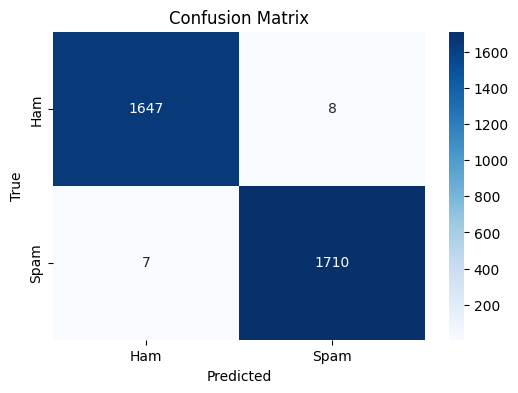

ROC AUC Score: 0.9999


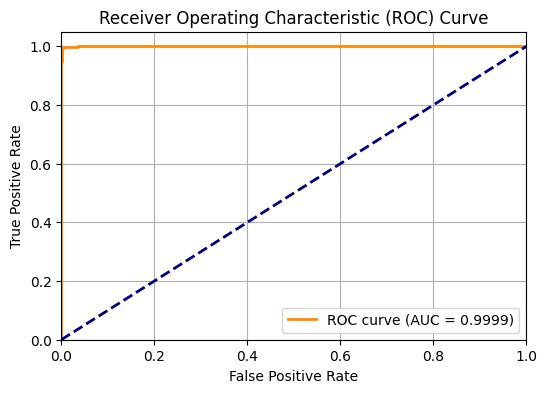

Average Precision Score: 0.9999


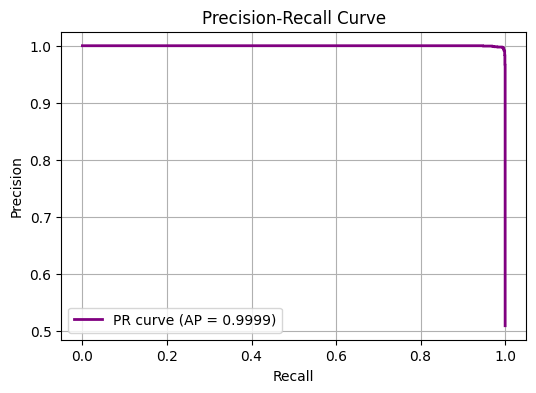

Summary of Evaluation Metrics:
MCC: 0.9911
ROC AUC: 0.9999
Average Precision: 0.9999


In [15]:
# Train and evaluate
best_val_loss = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device)
metrics = evaluate_model(model, test_loader, device)
# Optionally print or save specific metrics
print("Summary of Evaluation Metrics:")
print(f"MCC: {metrics['mcc']:.4f}")
print(f"ROC AUC: {metrics['roc_auc']:.4f}")
print(f"Average Precision: {metrics['average_precision']:.4f}")